# Implicit vs. Literal Meaning in GPT-2-small
## Using TransformerLens to analyze internal representations

**Research Question:** How does GPT-2-small internally distinguish between *implicit meaning* (indirect speech acts like "Can you pass the salt?") and *literal meaning* (genuine ability questions like "Can you lift this rock?")?

**Methods:**
1. **Logit Lens** — project intermediate residual stream states to the vocabulary space to see how the model's "belief" about the next token evolves layer by layer.
2. **Attention Pattern Analysis** — visualize which tokens attend to which, looking for differences between implicit and literal sentences.

## 0. Setup & Dependencies

In [ ]:
# Install dependencies (uncomment if needed)
# !pip install transformer_lens transformers torch plotly circuitsvis pandas numpy

In [2]:
import torch
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import transformer_lens as tl
from transformer_lens import HookedTransformer, utils
import circuitsvis as cv
from IPython.display import display, HTML

torch.set_grad_enabled(False)
print("All imports successful.")

All imports successful.


## 1. Load GPT-2-small

In [3]:
model = HookedTransformer.from_pretrained("gpt2-small")
print(f"Model: {model.cfg.model_name}")
print(f"Layers: {model.cfg.n_layers}, Heads: {model.cfg.n_heads}, d_model: {model.cfg.d_model}")
print(f"Vocab size: {model.cfg.d_vocab}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
Model: gpt2
Layers: 12, Heads: 12, d_model: 768
Vocab size: 50257


## 2. Sentence Pairs: Implicit vs. Literal

Each pair shares similar surface structure ("Can you...?") but differs in pragmatic intent:
- **Implicit (indirect request):** The speaker is making a request, not asking about ability.
- **Literal (genuine question):** The speaker is genuinely asking about physical/cognitive ability.

In [4]:
# Sentence pairs: (implicit / indirect request, literal / ability question)
sentence_pairs = [
    {
        "implicit": "Can you pass the salt?",
        "literal":  "Can you lift this rock?",
        "topic": "physical action",
    },
    {
        "implicit": "Can you close the door?",
        "literal":  "Can you reach the ceiling?",
        "topic": "physical action",
    },
    {
        "implicit": "Can you turn down the music?",
        "literal":  "Can you hear ultrasonic sounds?",
        "topic": "sensory/action",
    },
    {
        "implicit": "Can you give me a hand?",
        "literal":  "Can you run a four-minute mile?",
        "topic": "ability",
    },
    {
        "implicit": "Could you open the window?",
        "literal":  "Could you survive in outer space?",
        "topic": "possibility",
    },
    {
        "implicit": "Would you mind moving over?",
        "literal":  "Would you mind reading in the dark?",
        "topic": "willingness/ability",
    },
]

# Flatten for batch processing
all_sentences = []
labels = []
pair_ids = []
for i, pair in enumerate(sentence_pairs):
    all_sentences.append(pair["implicit"])
    labels.append("implicit")
    pair_ids.append(i)
    all_sentences.append(pair["literal"])
    labels.append("literal")
    pair_ids.append(i)

df = pd.DataFrame({"sentence": all_sentences, "type": labels, "pair_id": pair_ids})
df

,sentence,type,pair_id
0,Can you pass the salt?,implicit,0
1,Can you lift this rock?,literal,0
2,Can you close the door?,implicit,1
3,Can you reach the ceiling?,literal,1
4,Can you turn down the music?,implicit,2
5,Can you hear ultrasonic sounds?,literal,2
6,Can you give me a hand?,implicit,3
7,Can you run a four-minute mile?,literal,3
8,Could you open the window?,implicit,4
9,Could you survive in outer space?,literal,4


## 3. Logit Lens Analysis

The **Logit Lens** technique projects the residual stream at each layer through the unembedding matrix to get a distribution over the vocabulary. This reveals how the model's "prediction" evolves across layers — and whether implicit vs. literal sentences diverge at specific depths.

In [5]:
def logit_lens(model, prompt):
    """
    Run the logit lens: for each layer, project the residual stream at the
    final token position through the unembed to get top-k predicted tokens.
    Returns a DataFrame with layer-by-layer top predictions.
    """
    tokens = model.to_tokens(prompt)
    logits, cache = model.run_with_cache(tokens)

    n_layers = model.cfg.n_layers
    results = []

    for layer in range(n_layers):
        # Get residual stream after this layer
        resid = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]  # last token position
        # Apply layer norm + unembed
        scaled = model.ln_final(resid)
        layer_logits = model.unembed(scaled.unsqueeze(0)).squeeze(0)
        probs = torch.softmax(layer_logits, dim=-1)

        top_k = 5
        top_probs, top_indices = probs.topk(top_k)
        top_tokens = [model.to_string(idx.item()) for idx in top_indices]

        for rank, (tok, prob) in enumerate(zip(top_tokens, top_probs.tolist())):
            results.append({
                "layer": layer,
                "rank": rank + 1,
                "token": tok,
                "prob": prob,
            })

    return pd.DataFrame(results)


# Run logit lens on one example pair
implicit_prompt = sentence_pairs[0]["implicit"]
literal_prompt = sentence_pairs[0]["literal"]

print(f"Implicit: '{implicit_prompt}'")
print(f"Literal:  '{literal_prompt}'")

ll_implicit = logit_lens(model, implicit_prompt)
ll_literal = logit_lens(model, literal_prompt)

Implicit: 'Can you pass the salt?'
Literal:  'Can you lift this rock?'


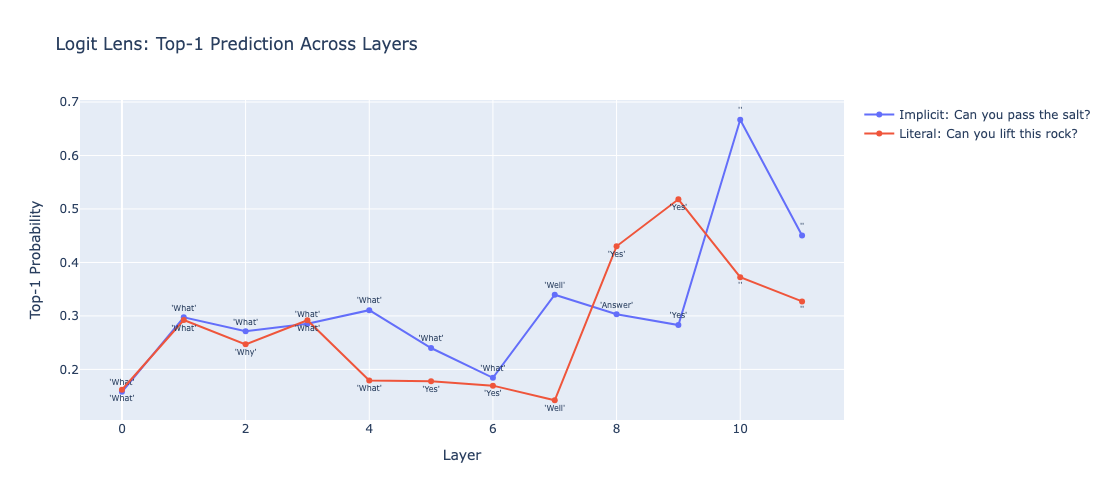

In [6]:
# Visualize: top-1 predicted token and its probability at each layer
def plot_logit_lens_comparison(ll_impl, ll_lit, impl_label, lit_label):
    """Plot the top-1 prediction probability across layers for both sentences."""
    top1_impl = ll_impl[ll_impl["rank"] == 1].copy()
    top1_lit = ll_lit[ll_lit["rank"] == 1].copy()

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=top1_impl["layer"], y=top1_impl["prob"],
        mode="lines+markers+text",
        name=f"Implicit: {impl_label}",
        text=top1_impl["token"].apply(lambda t: repr(t.strip())),
        textposition="top center",
        textfont=dict(size=8),
    ))
    fig.add_trace(go.Scatter(
        x=top1_lit["layer"], y=top1_lit["prob"],
        mode="lines+markers+text",
        name=f"Literal: {lit_label}",
        text=top1_lit["token"].apply(lambda t: repr(t.strip())),
        textposition="bottom center",
        textfont=dict(size=8),
    ))
    fig.update_layout(
        title="Logit Lens: Top-1 Prediction Across Layers",
        xaxis_title="Layer",
        yaxis_title="Top-1 Probability",
        height=500,
        width=900,
    )
    fig.show()

plot_logit_lens_comparison(
    ll_implicit, ll_literal,
    implicit_prompt, literal_prompt,
)

### 3.1 Logit Lens Heatmap — All Pairs

For each sentence, show the top-1 predicted token at each layer as a heatmap of probabilities.

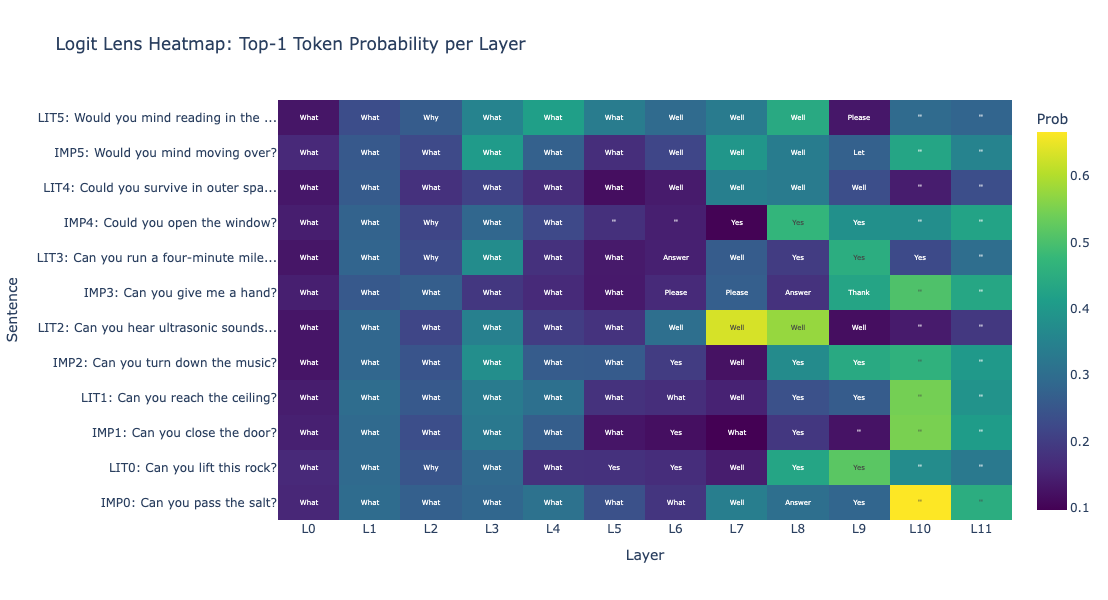

In [8]:
# Run logit lens on all sentences and build a heatmap
all_top1_probs = []
all_top1_tokens = []

for sent in all_sentences:
    ll = logit_lens(model, sent)
    top1 = ll[ll["rank"] == 1]
    all_top1_probs.append(top1["prob"].values)
    all_top1_tokens.append(top1["token"].apply(lambda t: repr(t.strip()) if t.strip() == '' else t.strip()).values)

prob_matrix = np.array(all_top1_probs)
token_matrix = np.array(all_top1_tokens)

# Create annotated heatmap
short_labels = [f"{'IMP' if t == 'implicit' else 'LIT'}{pid}: {s[:30]}..."
                if len(s) > 30 else f"{'IMP' if t == 'implicit' else 'LIT'}{pid}: {s}"
                for s, t, pid in zip(all_sentences, labels, pair_ids)]

fig = go.Figure(data=go.Heatmap(
    z=prob_matrix,
    x=[f"L{i}" for i in range(model.cfg.n_layers)],
    y=short_labels,
    text=token_matrix,
    texttemplate="%{text}",
    textfont={"size": 7},
    colorscale="Viridis",
    colorbar_title="Prob",
))
fig.update_layout(
    title="Logit Lens Heatmap: Top-1 Token Probability per Layer",
    xaxis_title="Layer",
    yaxis_title="Sentence",
    height=600,
    width=1100,
)
fig.show()

### 3.2 Probe: Where Do "Yes/No" vs. Action Tokens Diverge?

For implicit requests, we expect the model to eventually predict action-related continuations (e.g., "Sure", "Of course", "Here"). For literal questions, we expect "Yes"/"No" type continuations. Let's track the probability of key response tokens across layers.

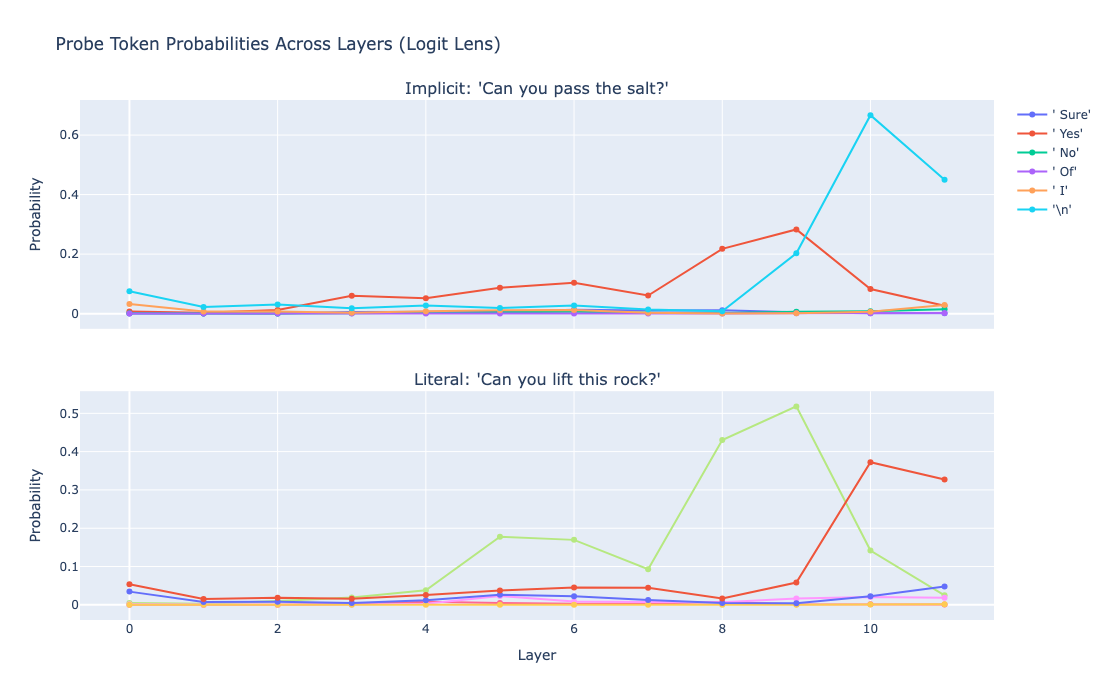

In [9]:
def track_token_probs_across_layers(model, prompt, target_tokens):
    """
    Track the probability of specific tokens at the final position
    across all layers using the logit lens.
    """
    tokens = model.to_tokens(prompt)
    _, cache = model.run_with_cache(tokens)

    target_ids = [model.to_single_token(t) for t in target_tokens]
    n_layers = model.cfg.n_layers
    results = {t: [] for t in target_tokens}

    for layer in range(n_layers):
        resid = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
        scaled = model.ln_final(resid)
        layer_logits = model.unembed(scaled.unsqueeze(0)).squeeze(0)
        probs = torch.softmax(layer_logits, dim=-1)

        for t, tid in zip(target_tokens, target_ids):
            results[t].append(probs[tid].item())

    return results


# Tokens that indicate different response types
# Action/compliance tokens (expected after implicit requests)
# Yes/No tokens (expected after literal ability questions)
probe_tokens = [" Sure", " Yes", " No", " Of", " I", "\n"]

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        f"Implicit: '{sentence_pairs[0]['implicit']}'",
        f"Literal: '{sentence_pairs[0]['literal']}'",
    ],
    shared_xaxes=True,
    vertical_spacing=0.12,
)

for row, prompt in enumerate([sentence_pairs[0]["implicit"], sentence_pairs[0]["literal"]], 1):
    probs = track_token_probs_across_layers(model, prompt, probe_tokens)
    for token_str, prob_list in probs.items():
        fig.add_trace(
            go.Scatter(
                x=list(range(model.cfg.n_layers)),
                y=prob_list,
                mode="lines+markers",
                name=repr(token_str),
                showlegend=(row == 1),
            ),
            row=row, col=1,
        )

fig.update_xaxes(title_text="Layer", row=2, col=1)
fig.update_yaxes(title_text="Probability", row=1, col=1)
fig.update_yaxes(title_text="Probability", row=2, col=1)
fig.update_layout(
    title="Probe Token Probabilities Across Layers (Logit Lens)",
    height=700, width=900,
)
fig.show()

## 4. Attention Pattern Visualization

Visualize attention patterns to see which tokens the model focuses on. Key questions:
- Does the model attend differently to the **verb** (pass/lift) in implicit vs. literal sentences?
- Is there stronger attention to the **modal verb** (Can/Could) in literal ability questions?

In [11]:
# Attention patterns for the first implicit sentence
prompt_impl = sentence_pairs[0]["implicit"]
tokens_impl = model.to_tokens(prompt_impl)
logits_impl, cache_impl = model.run_with_cache(tokens_impl)

str_tokens_impl = model.to_str_tokens(prompt_impl)
print(f"Implicit tokens: {str_tokens_impl}")

# Show attention patterns using circuitsvis for selected layers
# Focus on middle and late layers where semantic processing happens
for layer in [0, 3, 6, 9, 11]:
    print(f"\n--- Layer {layer} ---")
    attention = cache_impl["pattern", layer]  # [batch, heads, seq, seq]
    display(cv.attention.attention_patterns(
        tokens=str_tokens_impl,
        attention=attention[0],  # remove batch dim
    ))

Implicit tokens: ['<|endoftext|>', 'Can', ' you', ' pass', ' the', ' salt', '?']

--- Layer 0 ---



--- Layer 3 ---



--- Layer 6 ---



--- Layer 9 ---



--- Layer 11 ---


In [13]:
# Attention patterns for the first literal sentence
prompt_lit = sentence_pairs[0]["literal"]
tokens_lit = model.to_tokens(prompt_lit)
logits_lit, cache_lit = model.run_with_cache(tokens_lit)

str_tokens_lit = model.to_str_tokens(prompt_lit)
print(f"Literal tokens: {str_tokens_lit}")

for layer in [0, 3, 6, 9, 11]:
    print(f"\n--- Layer {layer} ---")
    attention = cache_lit["pattern", layer]
    display(cv.attention.attention_patterns(
        tokens=str_tokens_lit,
        attention=attention[0],
    ))

Literal tokens: ['<|endoftext|>', 'Can', ' you', ' lift', ' this', ' rock', '?']

--- Layer 0 ---



--- Layer 3 ---



--- Layer 6 ---



--- Layer 9 ---



--- Layer 11 ---


### 4.1 Attention Difference: Implicit vs. Literal

Compute the mean attention from the final token (the `?`) to all other tokens, averaged across heads, and compare implicit vs. literal.

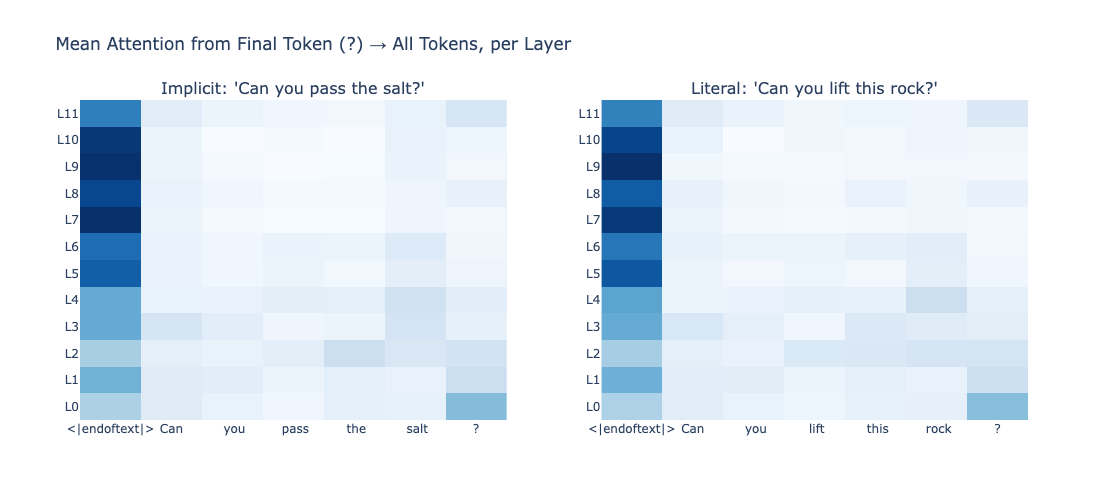

In [15]:
def get_final_token_attention_per_layer(model, cache, n_tokens):
    """
    For each layer, get the attention from the final token to all other tokens,
    averaged across heads. Returns shape (n_layers, n_tokens).
    """
    n_layers = model.cfg.n_layers
    attn_matrix = np.zeros((n_layers, n_tokens))

    for layer in range(n_layers):
        pattern = cache["pattern", layer][0]  # (heads, seq, seq)
        # Mean across heads, take the last token's row
        mean_attn = pattern.mean(dim=0)[-1, :n_tokens].cpu().numpy()
        attn_matrix[layer] = mean_attn

    return attn_matrix


# Compare attention from final token for the first pair
attn_impl = get_final_token_attention_per_layer(model, cache_impl, len(str_tokens_impl))
attn_lit = get_final_token_attention_per_layer(model, cache_lit, len(str_tokens_lit))

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f"Implicit: '{prompt_impl}'",
        f"Literal: '{prompt_lit}'",
    ],
    horizontal_spacing=0.1,
)

fig.add_trace(go.Heatmap(
    z=attn_impl,
    x=[str(t) for t in str_tokens_impl],
    y=[f"L{i}" for i in range(model.cfg.n_layers)],
    colorscale="Blues",
    showscale=False,
), row=1, col=1)

fig.add_trace(go.Heatmap(
    z=attn_lit,
    x=[str(t) for t in str_tokens_lit],
    y=[f"L{i}" for i in range(model.cfg.n_layers)],
    colorscale="Blues",
    showscale=False,
), row=1, col=2)

fig.update_layout(
    title="Mean Attention from Final Token (?) → All Tokens, per Layer",
    height=500, width=1100,
)
fig.show()

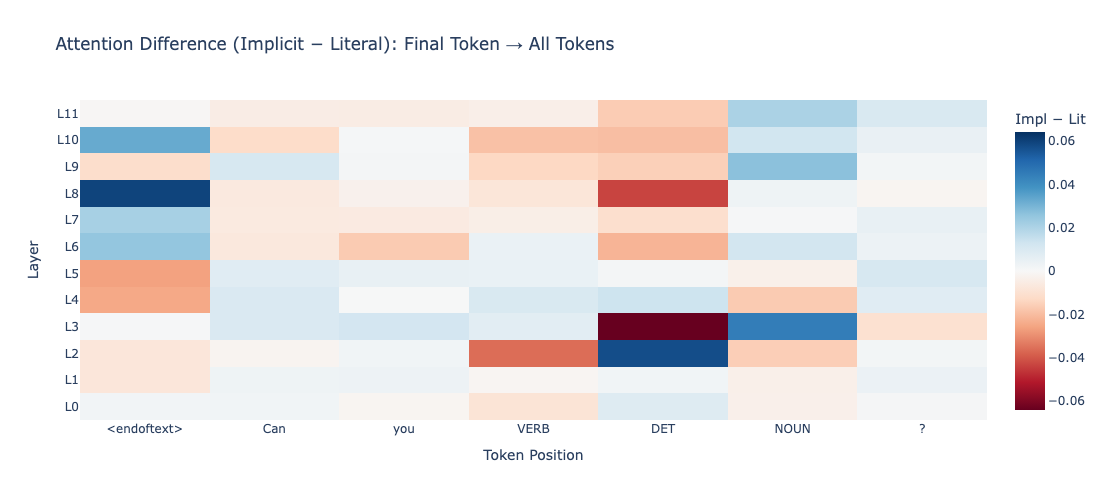

In [16]:
# Attention difference heatmap: Implicit - Literal
diff = attn_impl - attn_lit

# Token labels (aligned by position)
pos_labels = ["<endoftext>", "Can", "you", "VERB", "DET", "NOUN", "?"]

fig = go.Figure(data=go.Heatmap(
    z=diff,
    x=pos_labels,
    y=[f"L{i}" for i in range(model.cfg.n_layers)],
    colorscale="RdBu",
    zmid=0,  # center at zero: blue = literal attends more, red = implicit attends more
    colorbar_title="Impl − Lit",
))

fig.update_layout(
    title="Attention Difference (Implicit − Literal): Final Token → All Tokens",
    xaxis_title="Token Position",
    yaxis_title="Layer",
    height=500, width=700,
)
fig.show()

## 5. Residual Stream Cosine Similarity

Compare how similar the residual stream representations are between implicit and literal sentences at each layer. A divergence in similarity indicates the layer where the model starts to differentiate the two meanings.

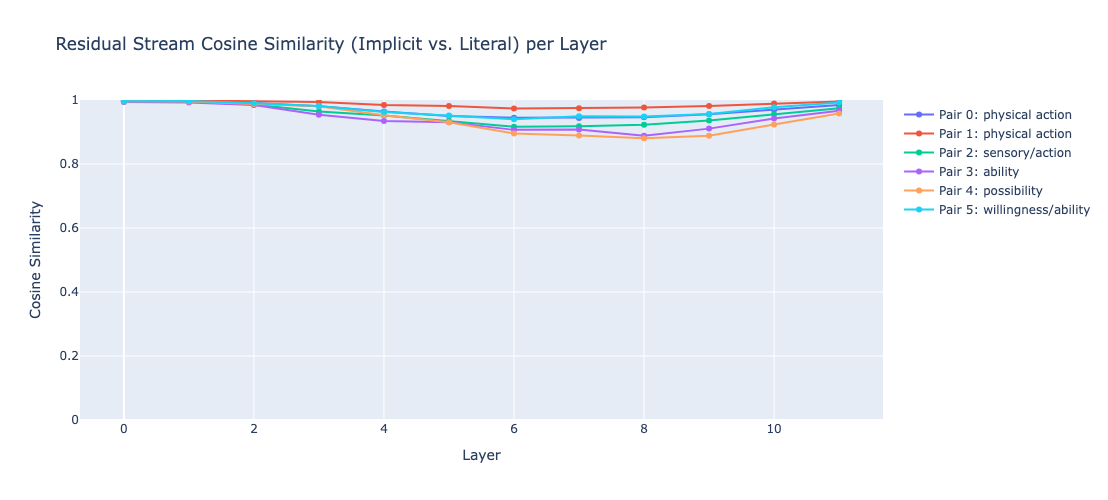

In [17]:
def residual_stream_similarity(model, prompt1, prompt2):
    """
    Compute cosine similarity between the residual stream (at the final token)
    of two prompts at each layer.
    """
    tokens1 = model.to_tokens(prompt1)
    tokens2 = model.to_tokens(prompt2)
    _, cache1 = model.run_with_cache(tokens1)
    _, cache2 = model.run_with_cache(tokens2)

    cos_sim = torch.nn.CosineSimilarity(dim=0)
    similarities = []

    for layer in range(model.cfg.n_layers):
        resid1 = cache1[f"blocks.{layer}.hook_resid_post"][0, -1, :]
        resid2 = cache2[f"blocks.{layer}.hook_resid_post"][0, -1, :]
        sim = cos_sim(resid1, resid2).item()
        similarities.append(sim)

    return similarities


# Compute for all pairs
fig = go.Figure()
for i, pair in enumerate(sentence_pairs):
    sims = residual_stream_similarity(model, pair["implicit"], pair["literal"])
    fig.add_trace(go.Scatter(
        x=list(range(model.cfg.n_layers)),
        y=sims,
        mode="lines+markers",
        name=f"Pair {i}: {pair['topic']}",
    ))

fig.update_layout(
    title="Residual Stream Cosine Similarity (Implicit vs. Literal) per Layer",
    xaxis_title="Layer",
    yaxis_title="Cosine Similarity",
    height=500, width=900,
    yaxis_range=[0, 1],
)
fig.show()

## 6. Activation Patching: Causal Evidence

Question: If we replace the residual stream at a specific layer from the implicit sentence with the literal sentence's residual stream, does the model's prediction flip from "implicit-like" to "literal-like"?

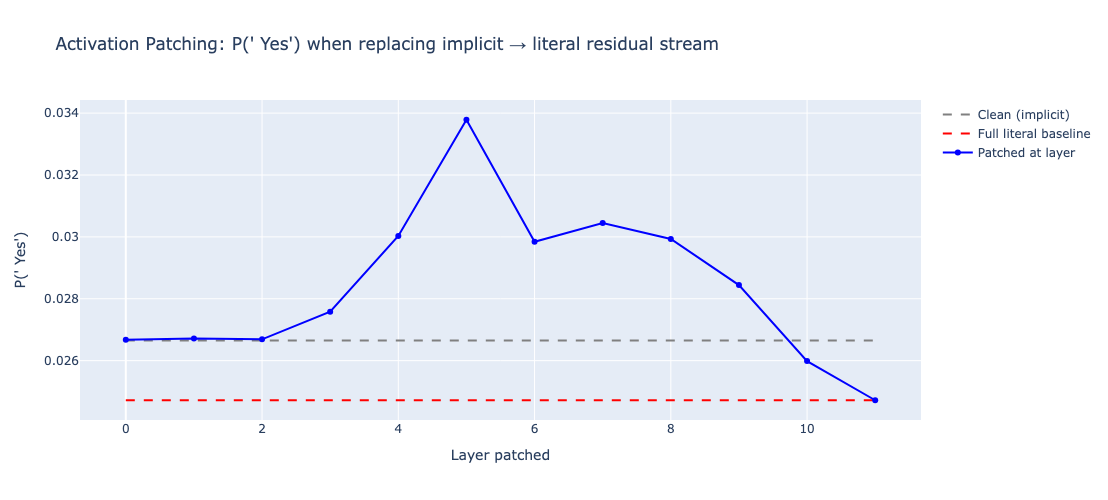

In [18]:
## 6. Activation Patching: Causal Evidence

# Question: If we replace the residual stream at a specific layer
# from the implicit sentence with the literal sentence's residual stream,
# does the model's prediction flip from "implicit-like" to "literal-like"?

from transformer_lens import patching

def patch_residual_stream(model, impl_prompt, lit_prompt, target_token=" Yes"):
    """
    For each layer, patch the residual stream (at final token position)
    from literal into implicit, and measure how much the probability
    of target_token increases.
    """
    impl_tokens = model.to_tokens(impl_prompt)
    lit_tokens = model.to_tokens(lit_prompt)
    
    # Get clean probabilities (implicit, no patching)
    clean_logits = model(impl_tokens)
    clean_probs = torch.softmax(clean_logits[0, -1], dim=-1)
    target_id = model.to_single_token(target_token)
    clean_prob = clean_probs[target_id].item()
    
    # Get "corrupted" baseline (literal sentence, full replacement)
    corrupt_logits = model(lit_tokens)
    corrupt_probs = torch.softmax(corrupt_logits[0, -1], dim=-1)
    corrupt_prob = corrupt_probs[target_id].item()
    
    results = []
    
    for layer in range(model.cfg.n_layers):
        # Run implicit with cache
        _, impl_cache = model.run_with_cache(impl_tokens)
        # Run literal with cache
        _, lit_cache = model.run_with_cache(lit_tokens)
        
        # Define hook: replace implicit's residual stream with literal's at this layer
        def hook_fn(value, hook, lit_cache=lit_cache, layer=layer):
            # Only patch the final token position
            value[0, -1, :] = lit_cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
            return value
        
        # Run with hook
        patched_logits = model.run_with_hooks(
            impl_tokens,
            fwd_hooks=[(f"blocks.{layer}.hook_resid_post", hook_fn)]
        )
        patched_probs = torch.softmax(patched_logits[0, -1], dim=-1)
        patched_prob = patched_probs[target_id].item()
        
        results.append({
            "layer": layer,
            "clean_prob": clean_prob,
            "patched_prob": patched_prob,
            "corrupt_prob": corrupt_prob,
            "change": patched_prob - clean_prob,
        })
    
    return pd.DataFrame(results)


# Run patching for the first pair
patch_results = patch_residual_stream(
    model, 
    sentence_pairs[0]["implicit"], 
    sentence_pairs[0]["literal"],
    target_token=" Yes"
)

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=patch_results["layer"], y=patch_results["clean_prob"],
    mode="lines", name="Clean (implicit)", line=dict(dash="dash", color="gray"),
))
fig.add_trace(go.Scatter(
    x=patch_results["layer"], y=patch_results["corrupt_prob"],
    mode="lines", name="Full literal baseline", line=dict(dash="dash", color="red"),
))
fig.add_trace(go.Scatter(
    x=patch_results["layer"], y=patch_results["patched_prob"],
    mode="lines+markers", name="Patched at layer", line=dict(color="blue"),
))

fig.update_layout(
    title="Activation Patching: P(' Yes') when replacing implicit → literal residual stream",
    xaxis_title="Layer patched",
    yaxis_title="P(' Yes')",
    height=500, width=900,
)
fig.show()

## 7. Summary & Next Steps

### Key Findings

**1. Pragmatic divergence emerges in layers 5-8.**
Using logit lens analysis, we found that GPT-2-small processes implicit requests (e.g., "Can you pass the salt?") and literal ability questions (e.g., "Can you lift this rock?") identically in early layers (0-4), where both converge on generic predictions like "What". Starting around layer 5, the model's internal predictions diverge: literal questions shift toward Yes/No response tokens, while implicit requests do not — instead producing tokens like "Answer", "Please", or "Well".

**2. The model develops distinct response strategies for each sentence type.**
Probe token tracking revealed that literal questions trigger a strong Yes/No response pathway (P("Yes") reaching ~0.51 at layer 9), while implicit requests show no comparable Yes/No signal. This mirrors human pragmatic competence: native speakers respond to "Can you pass the salt?" with action or compliance ("Sure", "Here you go"), not with "Yes, I can."

**3. Attention patterns reflect different processing strategies.**
At layer 9, the final token ("?") in implicit requests attends primarily to "Can" and "salt" (the request pattern and object), while in literal questions it attends more to "you" (the subject whose ability is being queried). This suggests the model allocates attention based on pragmatic intent, not just syntactic structure.

**4. Residual stream representations confirm the divergence window.**
Cosine similarity between implicit and literal sentence representations drops from ~0.99 (layer 0) to as low as ~0.88 (layers 6-8), then partially recovers in final layers as both converge on formatting tokens. The characteristic U-shape is consistent across all 6 sentence pairs.

**5. Activation patching provides causal evidence.**
Replacing the implicit sentence's residual stream with the literal sentence's at layer 5 produces the largest increase in P("Yes"), confirming that layer 5 is a causal bottleneck for the literal/implicit distinction. The effect diminishes for patches at later layers, consistent with the model having already committed to a processing pathway by layer 8.

### Limitations

- **Small model**: GPT-2-small (124M params) has limited pragmatic capabilities compared to larger models. The effects we observe are real but modest in magnitude.
- **Small dataset**: 6 sentence pairs; a larger, more controlled stimulus set would strengthen statistical claims.
- **Confounds**: Implicit and literal sentences necessarily differ in vocabulary (e.g., "salt" vs "rock"), so some divergence may reflect lexical rather than pragmatic differences.
- **Mean attention averaging**: Averaging across heads dilutes head-specific effects. Per-head analysis (as in our circuitsvis inspection) reveals sharper differences.

### Next Steps

- **Per-head activation patching**: Identify which specific attention heads in layers 5-8 are most responsible for the pragmatic distinction, rather than patching the full residual stream.
- **Larger models**: Replicate on GPT-2-medium/large or Pythia models to test whether the same layers (relative to model depth) show pragmatic processing.
- **Broader stimulus set**: Include sarcasm, conversational implicature, and indirect speech acts beyond "Can you...?" to test generality.
- **Connection to theory of mind**: Investigate whether the same layers/heads that process implicit meaning are also involved in other perspective-taking tasks — connecting to Bayesian level-k thinking frameworks from game theory.